---
title: Advanced Statistical Data Analysis
authors:
  - name: Anna Drewek
    affiliation: ZHAW School of Engineering
  - name: Andreas Ruckstuhl
    affiliation: ZHAW School of Engineering
exports:
- format: pdf
  template: https://github.com/marbetschar/plain_latex_article/archive/refs/heads/main.zip
  output: Advanced-Statistical-Data-Analysis.pdf
  id: advanced-statistical-data-analysis-pdf
downloads:
  - id: advanced-statistical-data-analysis-pdf
    title: Download as PDF
---

In [1]:
# Install BiocManager (if not already installed)
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Install graph and RBGL from Bioconductor
BiocManager::install(c("graph", "RBGL", "Rgraphviz"))

install.packages("gRbase")
install.packages("pcalg")

library(gRbase)

set.seed(123)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'graph' 'RBGL' 'Rgraphviz'”
Warning message in .available.both(repos, method, ...):
“Some listed binary packages have no source”
Old packages: 'boot', 'class', 'cluster', 'codetools', 'DEoptimR', 'foreign',
  'KernSmooth', 'lattice', 'MASS', 'Matrix', 'mgcv', 'nlme', 'nnet', 'rpart',
  'spatial', 'survival'




The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//Rtmp2VjdEg/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//Rtmp2VjdEg/downloaded_packages


## Overview

```{prf:definition} Statistical Data Analysis}
Statistical data analysis is the science of collecting, exploring, and presenting (large amounts of) data to discover underlying patterns and trends which are hidden by random noise.
```

The course focuses on **regression modeling** as a primary tool for explaining relationships between:
- **Response variable** (output/dependent variable): The variable we want to explain or predict
- **Explanatory variables** (inputs/independent variables/predictors): Variables that explain the response

**Mathematical Formulation:**
$$Y \approx f\left\langle X^{(1)}, X^{(2)}, \ldots, X^{(m)}\right\rangle + E$$
where $f\left\langle \cdot \right\rangle$ is the systematic component and $E$ is the random error term.

### Symbols

| Symbol | Meaning | Example                                    |
|--------|---------|--------------------------------------------|
| $Y$ | Response variable | $Y_i$                                      |
| $X$ | Explanatory variable | $X_j$                                      |
| $\beta$ | Regression coefficient | $\beta_0$, $\beta_1$                       |
| $\mu$ | Expectation | $\mu = \mathbb{E}[Y]$                      |
| $\sigma^2$ | Variance | $\text{Var}(Y) = \sigma^2$                 |
| $\phi$ | Dispersion parameter | $\phi V(\mu)$                              |
| $\eta$ | Linear predictor | $\eta = \underline{X}^T \underline{\beta}$ |
| $g(\cdot)$ | Link function | $g(\mu) = \eta$                            |
| $P(\cdot)$ | Probability | $P(Y \| X)$                                |
| $\text{do}(X=x)$ | Intervention | $P(Y \| \text{do}(X=x))$                   |

### Distributions

| Distribution | Notation | Mean | Variance |
|-------------|----------|------|----------|
| Normal | $\mathcal{N}(\mu, \sigma^2)$ | $\mu$ | $\sigma^2$ |
| Binomial | $\text{Binomial}(m, \pi)$ | $m\pi$ | $m\pi(1-\pi)$ |
| Poisson | $\text{Poisson}(\lambda)$ | $\lambda$ | $\lambda$ |
| Gamma | $\text{Gamma}(\alpha, \beta)$ | $\alpha/\beta$ | $\alpha/\beta^2$ |

## Advanced Regression Modelling

### Multiple Linear Regression

#### Objectives of Regression Analysis
1. General description of data structure.
2. Assessment of the effect of explanatory variables on the response.
3. Prediction of future observations.

:::{prf:definition} Multiple Linear Regression Model
:label: mlr-equation

The systematic relationship is explored via a function $f(\cdot)$:
$$Y_i = \beta_0 + \beta_1 x^{(1)}_i + \dots + \beta_m x^{(m)}_i + \mathcal{E}_i, \quad i = 1, \dots, n$$ (mlr-equation)

where $\mathcal{E}_i$ are unobservable random variables.
:::

:::{prf:remark}
In a **linear model**, the parameters enter linearly; the predictors themselves do not have to be linear. For example, $y \approx \beta_0 + \beta_1 x^{(1)} + \beta_2 \log(x^{(2)})$ is a linear model, but $y \approx \beta_0 + \beta_1 (x^{(1)})^{\beta_2}$ is not.
:::

#### Error Assumptions
The standard assumptions for the error terms $\mathcal{E}_i$ are:
- Stochastically independent.
- Expectation zero and constant variance $\sigma^2$ (homoscedasticity).
- Normally (Gaussian) distributed: $\mathcal{E}_i \sim \mathcal{N}(0, \sigma^2)$.

#### Matrix Representation

To simplify notation, the regression equation {eq}`mlr-equation` is written in matrix form:
$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\mathcal{E}}$$

where:
- $\mathbf{Y}$ is an $n \times 1$ vector of responses.
- $\mathbf{X}$ is an $n \times p$ matrix of explanatory variables (including a column of 1s for the intercept).
- $\boldsymbol{\beta}$ is a $p \times 1$ vector of unknown coefficients ($p = m+1$).
- $\boldsymbol{\mathcal{E}}$ is an $n \times 1$ vector of unobserved random variables.

#### Tukey's First-Aid Transformations

Standard recommendations used to linearize relationships and stabilize variance when there is no specific domain theory to guide variable transformation.
These should be applied to both explanatory variables and responses unless a valid reason exists to do otherwise:

| Data Type                      | Recommended Transformation                                                  |
|:-------------------------------|:----------------------------------------------------------------------------|
| **Concentrations and Amounts** | $\log(x)$                                                                   |
| **Count Data**                 | $\sqrt{x}$                                                                  |
| **Counted Fractions / Shares** | $\tilde{x} = \text{logit}(x) = \log\left(\frac{x + 0.005}{1.01 - x}\right)$[^logit-percentage] |

[^logit-percentage]: Modified logit transformation to avoid divison by zero for full range of percentage (0-100%).

#### Model Fitting and Diagnostics

##### Least Squares Estimation
The coefficients $\boldsymbol{\beta}$ are estimated by minimizing the sum of squared residuals.

:::{prf:theorem} Gauss-Markov Theorem
:label: thm-gauss-markov
Under the assumptions of zero mean, constant variance, and uncorrelated errors, the Ordinary Least Squares (OLS) estimator is the **Best Linear Unbiased Estimator (BLUE)**.
:::

The OLS estimator is given by:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$$

##### Model Adequacy (Residual Analysis)

Model adequacy is checked using diagnostic plots:

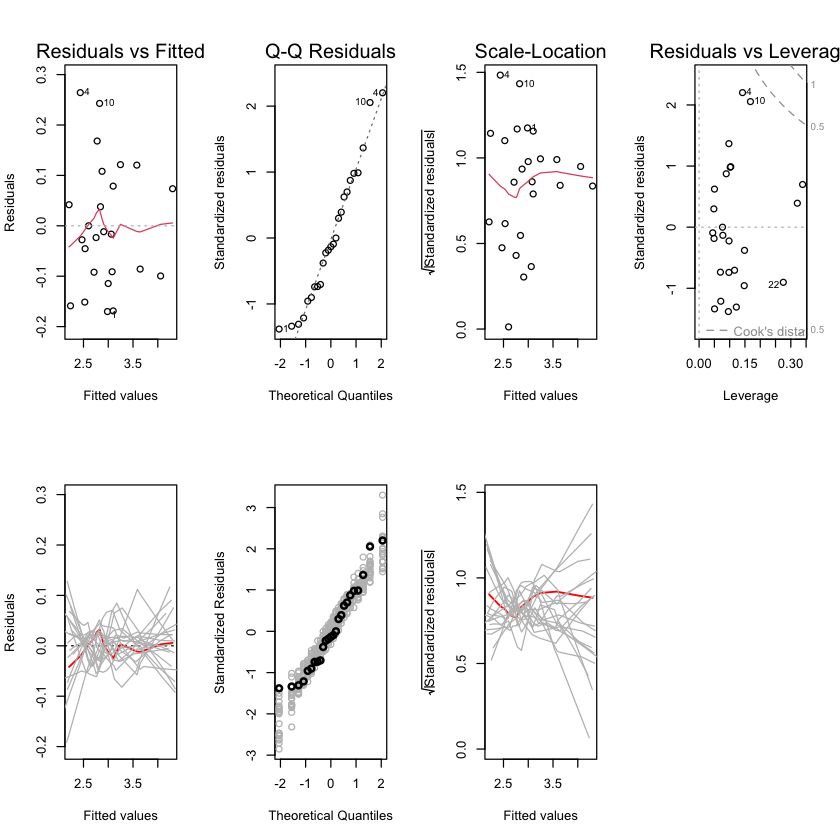

In [12]:
source("advanced-statistical-data-analysis/RFn_Plot-lmSim.R")
df <- read.table("advanced-statistical-data-analysis/Softdrink.dat", header=TRUE)

# Tukey's First-Aid Transformations:
df.tk <- data.frame(
  Time=log(df$Time),
  volume=sqrt(df$volume), # := number of cases of product stocked => count data
  distance=log(df$distance),
  location=df$location) # := categorical variable (text data)

# Linear Regression:
df.tk.lm1 <- lm(Time ~ volume + distance, data=df.tk)

# Residual Analysis:
par(mfrow=c(2,4))
plot(df.tk.lm1)
plot.lmSim(df.tk.lm1, SEED=4711)

- **Tukey-Anscombe Plot:** Residuals vs. Fitted values to check for non-linearity or heteroscedasticity.
- **Normal Q-Q Plot:** To check the normality assumption of errors.
- **Scale-Location Plot:** To check for constant variance.
- **Residuals vs. Leverage:** To identify influential observations (Cook's Distance).



**Model Formulation:**
$$Y_i = \beta_0 + \beta_1 x_i^{(1)} + \beta_2 x_i^{(2)} + \cdots + \beta_m x_i^{(m)} + E_i, \quad i = 1, \ldots, n$$

**Assumptions:**
1. $E_i \sim \mathcal{N}(0, \sigma^2)$ (normally distributed errors)
2. $\mathbb{E}[E_i] = 0$ (zero expectation)
3. $\text{Var}(E_i) = \sigma^2$ (homoscedasticity)
4. $E_i$ are stochastically independent
5. No perfect multicollinearity

**Matrix Notation:**
$$\underline{Y} = \boldsymbol{X} \underline{\beta} + \underline{E}$$

```{math}
:label: eq-linear-model
Y = X\beta + E
```

**Gauss-Markov Theorem:**
Under assumptions 1-4 (without normality), OLS is BLUE (Best Linear Unbiased Estimator).

**Properties:**
- Unbiased: $\mathbb{E}[\hat{\underline{\beta}}] = \underline{\beta}$
- Consistent: $\hat{\underline{\beta}} \xrightarrow{P} \underline{\beta}$
- Asymptotic Normality: $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1})$

:::{error} TODO
Variable Selection (AIC/BIC), Multicollinearity + VIF!
:::

### Advanced Topics in Linear Regression Modelling

#### Learning Objectives
- Weighted Least Squares (for non-constant variance)
- Robust Fitting (to handle outliers and leverage points)
- Fitting Smooth Functions (using LOESS and splines)
- Additive Regression Models
- Model Building strategies

#### Problem: OLS is _not_ robust

**Measuring Robustness**

How robust an estimator is, can be investigated by two simple measures:

- influence function and gross error sensitivity:
  The (gross error) sensitivity is based on the influence function and measures the maximum effect of a single observation on the estimated value
- breakdown point:
  returns the minimum proportion of data that can be altered without causing completely unreliable estimates

Hence an estimator with good robustness properties has:

- a bounded gross error sensitivity and
- a breakdown point of (about) 0.5

**Robust Regression: From OLS to MM-estimator**

| Estimator                           |Purpose|Problem Addressed|Weights|
|:------------------------------------|:--|:--|:--|
| OLS (Ordinary Least Squares)        |Standard regression|None (assumes ideal conditions)|All weights = 1|
| WLS (Weighted Least Squares)        |Efficiency improvement|Heteroscedasticity (non-constant variance)|Known from variance structure|
| M-estimator (Max Likelihood)        |Robustness|Outliers in response|Data-driven from residuals|
| S-estimator (Scale, $\sigma$)       |Robust scale|Outliers + leverage points|Implicit in scale estimation|
| MM-estimator (Modified M-estimator) |Best of both|Outliers + leverage + efficiency|Two-step: S then M|

We need S-estimators, M-estimators, and MM-estimators because real-world data often violates the assumptions of OLS regression. Therefore, we need robust estimators:

1. OLS has 0% breakdown point - even one bad data point can ruin your analysis
2. M-estimators alone can't handle leverage points - outliers in predictors are still problematic
3. S-estimators are too computationally expensive for routine use
4. MM-estimators give us the best of both worlds - robustness AND practicality

Use MM-estimators as your default robust regression method. They provide protection against both outliers and leverage points while maintaining good statistical efficiency.

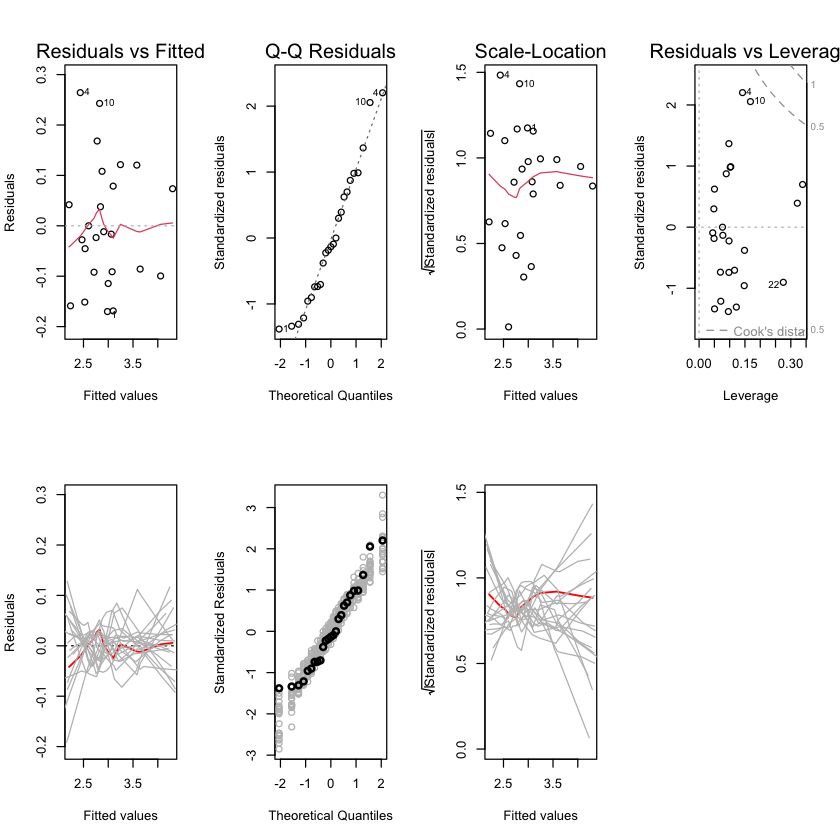

In [14]:
library(robustbase)
source("advanced-statistical-data-analysis/RFn_Plot-lmSim.R")
df <- read.table("advanced-statistical-data-analysis/Synthetic.dat", header=TRUE)

# Robust fit:
df.rlm <- lmrob(Y ~ x1 + x2, data=df, method="MM")

# Residual Analysis:
par(mfrow=c(2,4))
plot(df.tk.lm1)
plot.lmSim(df.tk.lm1, SEED=4711)

:::{error} TODO

- **Huber's method:** Quadratic loss for small residuals, linear for large
- **RLM:** Iteratively reweighted least squares with Huber's $\psi$ function

**Smooth Function Fitting:**
- **LOESS:** Locally weighted scatterplot smoothing
- **Splines:** Natural cubic, B-splines, thin plate splines

**Additive Models:**
$$g(\mu) = \beta_0 + \sum_{j=1}^m s_j(X_j)$$
:::

### Logistic Regression (Binary Regression)

#### Theoretical Background

**Logistic Regression Model:**
$$P(Y_i = 1 | \underline{X}_i) = \pi_i = \frac{1}{1 + e^{-\eta_i}}, \quad \eta_i = \underline{X}_i^T \underline{\beta}$$

**Logit Link:**
$$\log\left\langle \frac{\pi_i}{1 - \pi_i} \right\rangle = \eta_i$$

**Odds Ratio:**
$$\text{OR} = e^{\beta_j} = \frac{\text{Odds}(Y=1 | X_j = x+1)}{\text{Odds}(Y=1 | X_j = x)}$$

**Asymptotic Properties:**
- $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \mathcal{I}^{-1})$
- Wald tests valid for large samples

(Intercept)         Hours 
-3.9235965551  0.0009992372

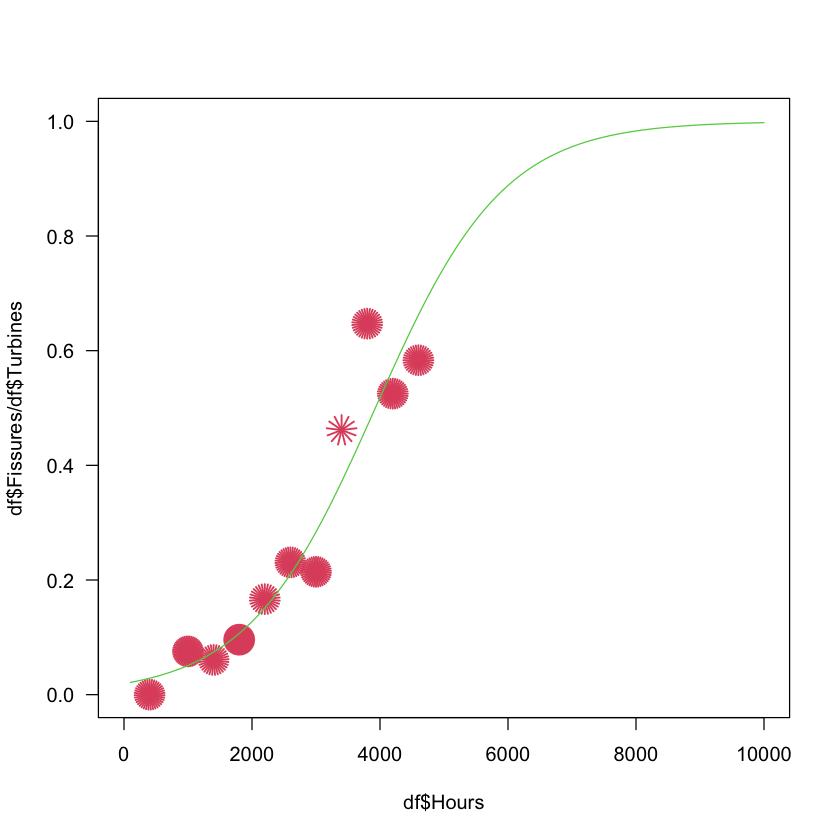

In [26]:
df <- read.table("advanced-statistical-data-analysis/turbines.dat", header = TRUE)

# glm format: glm(x ~ y, family=…, data=…)
df.glm <- glm(cbind(Fissures, Turbines-Fissures) ~ Hours, family=binomial, data=df)
coef(df.glm)

df.p <- data.frame(Hours=seq(100, 10000, by=100))
p.y <- predict(df.glm, newdata=N, type="response")
sunflowerplot(x=df$Hours, y=df$Fissures/df$Turbines, las=1, number=df$Turbines, xlim=c(0, 10000), ylim=c(0,1))
lines(p$Hours, p.y, col=3)

### Generalized Linear Models (GLM) - A Unifying Model Family

#### Theoretical Background

**GLM Structure:**
1. **Random:** $Y_i \sim \text{Exponential Family}(\mu_i, \phi)$
2. **Systematic:** $\eta_i = \underline{x}_i^T \underline{\beta}$
3. **Link:** $g(\mu_i) = \eta_i$

**Exponential Family:**
$$f(y_i; \mu_i, \phi) = \exp \left\langle \frac{y_i b(\mu_i) - c(\mu_i)}{\phi} w_i + d(y_i; \phi, w_i) \right\rangle$$

```{math}
:label: eq-exponential-family
f(y; \mu, \phi) = \exp\left\langle \frac{y b(\mu) - c(\mu)}{\phi} + d(y; \phi) \right\rangle
```

**Variance Function:**
$$\text{Var}(Y_i) = \frac{\phi}{w_i} V(\mu_i), \quad V(\mu_i) = \frac{1}{b''(\mu_i)}$$

**Common Distributions:**

| Distribution | Range | $\mu$ | Variance | Canonical Link | $V(\mu)$ |
|-------------|-------|-------|----------|----------------|-----------|
| Gaussian | $\mathbb{R}$ | $\mu$ | $\sigma^2$ | Identity | $1$ |
| Binomial | $\{0,...,m\}$ | $\pi$ | $\pi(1-\pi)/m$ | Logit | $\mu(1-\mu)$ |
| Poisson | $\{0,1,2,...\}$ | $\lambda$ | $\lambda$ | Log | $\mu$ |
| Gamma | $(0,\infty)$ | $\mu$ | $\mu^2/\nu$ | Inverse | $\mu^2$ |

**IRLS Algorithm:**
1. $z = \eta + (y - \mu) \frac{\partial \eta}{\partial \mu}$
2. $W = \text{diag}\left\langle \frac{w}{\phi V(\mu) (\frac{\partial \eta}{\partial \mu})^2} \right\rangle$
3. Fit weighted linear regression
4. Update and repeat

#### Learning Objectives
- Identify members of the exponential family
- Know the two basic elements that define the GLM
- Fit GLMs in R and know the algorithm underlying it
- Interpret R output of a GLM fit

#### Key R Code Snippets

```{code-block} R
---
name: glm-unifying
---
model_binomial <- glm(y ~ x1 + x2, family = binomial, data = mydata)
model_poisson <- glm(y ~ x1 + x2, family = poisson, data = mydata)
model_gamma <- glm(y ~ x1 + x2, family = Gamma, data = mydata)
model_gaussian <- glm(y ~ x1 + x2, family = gaussian, data = mydata)
```

```{code-block} R
---
name: glm-fitting
---
DaR.glm <- glm(RDR ~ sPOP + lAR + HR + sVH + F + IND,
               family = poisson, data = DaR)
par(mfrow = c(2, 4), mar = c(3.5, 3.5, 2, 1.5))
plot(DaR.glm)
```

### Week 6: Inference, Model Simplification, Variable Selection

#### Theoretical Background

**Deviance:**
$$D(\underline{y}, \hat{\underline{\mu}}) = 2 \sum_i \left\langle \ell(y_i; y_i) - \ell(y_i; \hat{\mu}_i) \right\rangle$$

**Deviance Test:**
$$\Delta D = D_0 - D_1 \sim \chi^2_{df_1 - df_0}$$

**Overdispersion:**
$$\hat{\phi} = \frac{\text{Residual Deviance}}{n - p}$$

**Confidence Intervals:**
- **Wald:** $\hat{\beta}_j \pm z_{\alpha/2} \cdot \text{SE}(\hat{\beta}_j)$
- **Deviance-based:** More accurate for small samples
- **Bootstrap:** Nonparametric

#### Learning Objectives
- Know what deviances are in GLM
- Know what overdispersion is and can identify it
- Know when to apply Wald-type vs deviance-based confidence intervals
- Apply methods in statistical data analysis using R

#### Key R Code Snippets

```{code-block} R
---
name: glm-deviances
---
model <- glm(y ~ x1 + x2, family = poisson, data = mydata)
null_deviance <- model$null.deviance
resid_deviance <- model$deviance
anova(model_simple, model_complex, test = "LRT")
```

```{code-block} R
---
name: glm-overdispersion
---
model_poisson <- glm(y ~ x1 + x2, family = poisson, data = mydata)
dispersion <- model_poisson$deviance / model_poisson$df.residual
if (dispersion > 1.5) {
  model_quasi <- glm(y ~ x1 + x2, family = quasipoisson, data = mydata)
  library(MASS)
  model_nb <- glm.nb(y ~ x1 + x2, data = mydata)
}
```

```{code-block} R
---
name: model-selection
---
AIC(model1, model2, model3)
BIC(model1, model2, model3)
step(model1, direction = "both")
```

---

### Week 7: Diagnostics / Model Adequacy Checking

#### Theoretical Background

**Diagnostic Plots:**
1. **Residuals vs Fitted:** Check linearity and homoscedasticity
2. **Normal Q-Q:** Check normality
3. **Scale-Location:** Check constant variance
4. **Leverage:** Identify influential points

**Multicollinearity:**
- High VIF (> 5 or 10) indicates problematic collinearity
- Effects: Unstable estimates, inflated standard errors

#### Learning Objectives
- Understand how AIC is generalized to GLMs
- Check model adequacy and determine which assumptions are violated
- Find appropriate transformations of predictors in a data-driven manner
- Apply methods in statistical data analysis using R

#### Key R Code Snippets

```{code-block} R
---
name: aic-glm
---
AIC(model1, model2)
```

```{code-block} R
---
name: glm-diagnostics
---
par(mfrow = c(2, 2))
plot(model_poisson, which = 1:4)
library(halfnorm)
halfnorm(residuals(model_poisson, type = "deviance"))
```

```{code-block} R
---
name: influence-measures
---
library(car)
cooks.distance(model1)
hat.values(model1)
dfbetas(model1)
```

---

### Week 8: Some Extensions of GLM

#### Theoretical Background

**Rate Models:**
$$\mathbb{E}[Y_i] = \mu_i = t_i \lambda_i$$
For Poisson with log link:
$$\log(\mu_i) = \log(t_i) + \log(\lambda_i) = \underline{x}_i^T \underline{\beta}$$

**Quasi Models:**
$$\text{Var}(Y_i) = \phi V(\mu_i)$$
- Consistent $\hat{\underline{\beta}}$ even if variance function misspecified
- Standard errors adjusted by $\hat{\phi}$

**Instrumental Variables:**
1. **First Stage:** $X = \pi_0 + \pi_1 Z + U$
2. **Second Stage:** $Y = \beta_0 + \beta_1 \hat{X} + E$

#### Learning Objectives
- Know what a rate model is and how to analyse it with GLM
- Know how a quasi model extends a GLM and when to apply it
- Fit methods to data, interpret results, make inference and predictions

#### Key R Code Snippets

```{code-block} R
---
name: rate-model
---
model_rate <- glm(y ~ x1 + x2, family = poisson, offset = log(t), data = mydata)
```

```{code-block} R
---
name: quasi-models
---
model_quasipoisson <- glm(y ~ x1 + x2, family = quasipoisson, data = mydata)
model_quasibinomial <- glm(cbind(Y, m-Y) ~ x1 + x2, family = quasibinomial, data = mydata)
```

```{code-block} R
---
name: instrumental-variables
---
library(AER)
model_iv <- ivreg(Y ~ X + W | Z + W, data = mydata)
summary(model_iv)
```

## Causality

### Introduction

#### Theoretical Background

```{warning}
Association does not imply causation.
```

**The Ladder of Causation (Pearl):**
1. **Association (Seeing):** Observing patterns
2. **Intervention (Doing):** Estimating effects of actions
3. **Counterfactuals (Imagining):** Reasoning about hypotheticals

**Notation:**
- $P(Y | X = x)$: Conditional probability
- $P(Y | \text{do}(X = x))$: Causal effect

**Causal Graphical Models:**
- **Nodes:** Variables
- **Edges:** Causal relationships
- **DAG:** Directed Acyclic Graph (no cycles)

**Graphical Structures:**
1. **Chain:** $X → Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
2. **Fork:** $X ← Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
3. **Collider:** $X → Z ← Y$
  - $X$ and $Y$ are **independent** $(X \perp\!\!\!\perp Y)$, but are **conditionally dependent** on Z and any descendants of Z; $(X \not\perp\!\!\!\perp Y \mid Z)$

```{math}
:label: def-dseparation
X \perp\!\!\!\perp Y \mid Z \text{ if all paths between X and Y are blocked by Z}
```

#### Learning Objectives
- Understand when and why causal reasoning is important
- Be familiar with causal graphical models
- Understand the difference between association, interventions, and counterfactuals
- Know the difference between experimental and observational data

#### Intervention changes distribution

![Intervention changes distribution 1](advanced-statistical-data-analysis/Intervention-changes-distribution-1.png)

![Intervention changes distribution 2](advanced-statistical-data-analysis/Intervention-changes-distribution-2.png)

#### Key R Code Snippets

In [4]:
library(gRbase)
g <- dag(
  c("A"),
  c("B", "A", "E"), # = root node + all incoming node-edges
  c("C", "A", "B", "D"),
  c("D", "B"),
  c("E")
)

cat("Children of B = ", children("B", g), "\n")
cat("Parents of B = ", parents("B", g), "\n")
cat("Ancestors of B = ", ancestralSet("B", g), "\n")

Children of B =  C D 
Parents of B =  A E 
Ancestors of B =  A B E 


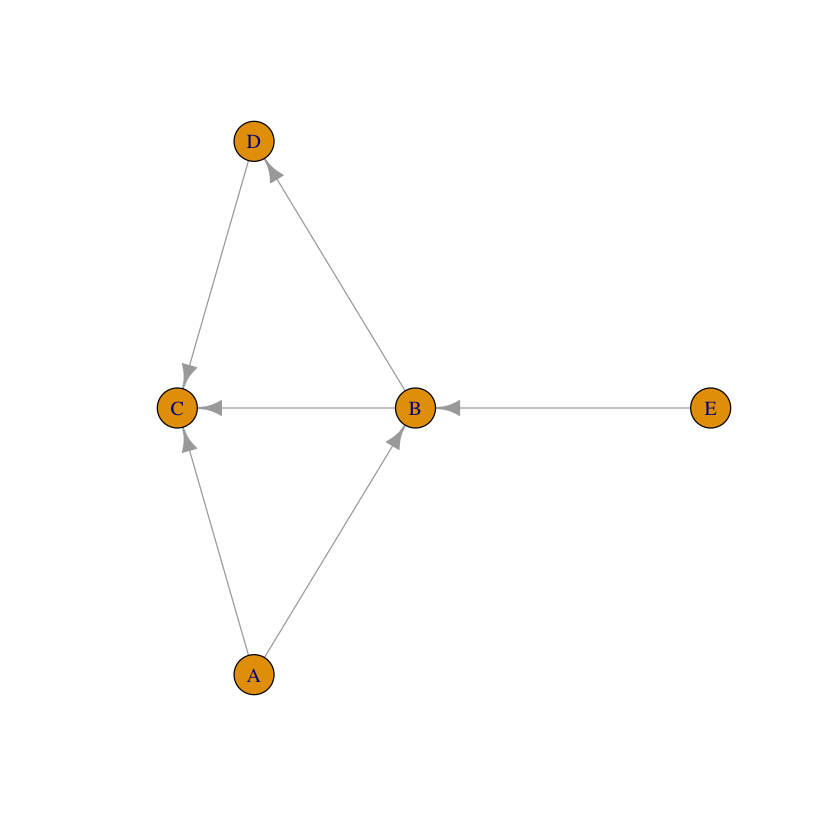

In [5]:
plot(g)

In [6]:
m <- as(g, "matrix") # to matrix from graph
m
g1 <- as(m, "igraph") # to igraph from matrix

,A,B,E,C,D
A,0,1,0,1,0
B,0,0,0,1,1
E,0,1,0,0,0
C,0,0,0,0,0
D,0,0,0,1,0


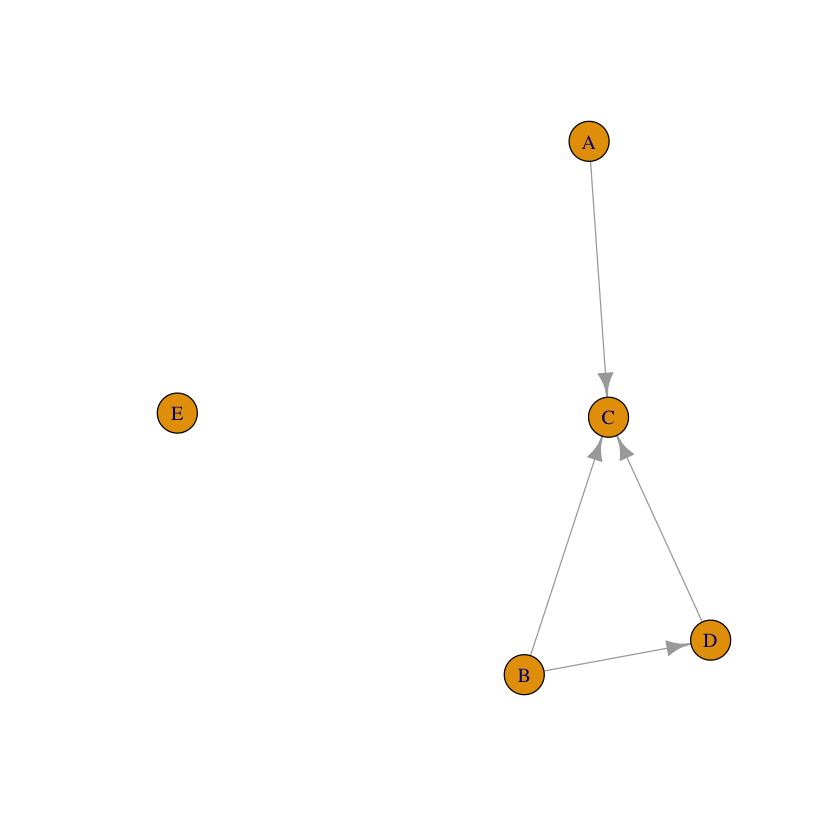

In [7]:
# Intervention on B (i.e. remove edges):
g2 <- removeEdge("A", "B", removeEdge("E", "B", g1))
plot(g2)

### Simpson's Paradox & Graphical Models

#### Theoretical Background

**Simpson's Paradox:**
A trend appears in different groups but disappears or reverses when combined.

**Factorization:**
- **Chain:** $P(X,Z,Y) = P(X)P(Z|X)P(Y|Z)$
- **Fork:** $P(X,Z,Y) = P(Z)P(X|Z)P(Y|Z)$
- **Collider:** $P(X,Z,Y) = P(X)P(Y)P(Z|X,Y)$

**Bayesian Network Factorization:**
$$P(X_1, \ldots, X_n) = \prod_{i=1}^n P(X_i | \text{Parents}(X_i))$$

#### Learning Objectives
- Understand Simpson's paradox and how to analyze it
- Express joint distribution by factorization
- Understand (conditional) independence
- Identify (conditional) independences for chain, fork, and collider

#### Key R Code Snippets

In [8]:
library(gRbase)
library(gRain)

graph.toys <- dag(c("Gender"), c("Toy","Gender"))
load("advanced-statistical-data-analysis/toys.rda")
gn <- grain(graph.toys, data = toys) # combine graph and data to a Bayesian network

In [9]:
# Conditional probability: from data
toys_girls <- toys[toys$Gender== "girl",]
cat("P(Toy = car | Gender = girl) =", sum(toys_girls== "car") / nrow(toys_girls))

# Conditional probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="conditional")

P(Toy = car | Gender = girl) = 0.3915344

,boy,girl
car,0.8931624,0.3915344
doll,0.1068376,0.6084656


In [10]:
# Joint probability: from data
n_car_girl <- sum(toys$Toy== "car" & toys$Gender== "girl")
cat("P(Toy = car, Gender = girl) =", n_car_girl/nrow(toys))

# Joint probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="joint")

P(Toy = car, Gender = girl) = 0.1749409

,car,doll
boy,0.4940898,0.05910165
girl,0.1749409,0.27186761


In [11]:
# marginal probabilities
querygrain(gn, nodes = "Gender", type = "marginal")
querygrain(gn, nodes = "Toy", type = "marginal")

$Gender
Gender
      boy      girl 
0.5531915 0.4468085

$Toy
Toy
      car      doll 
0.6690307 0.3309693

,boy,girl
car,0.8989899,0.3939394
doll,0.1010101,0.6060606


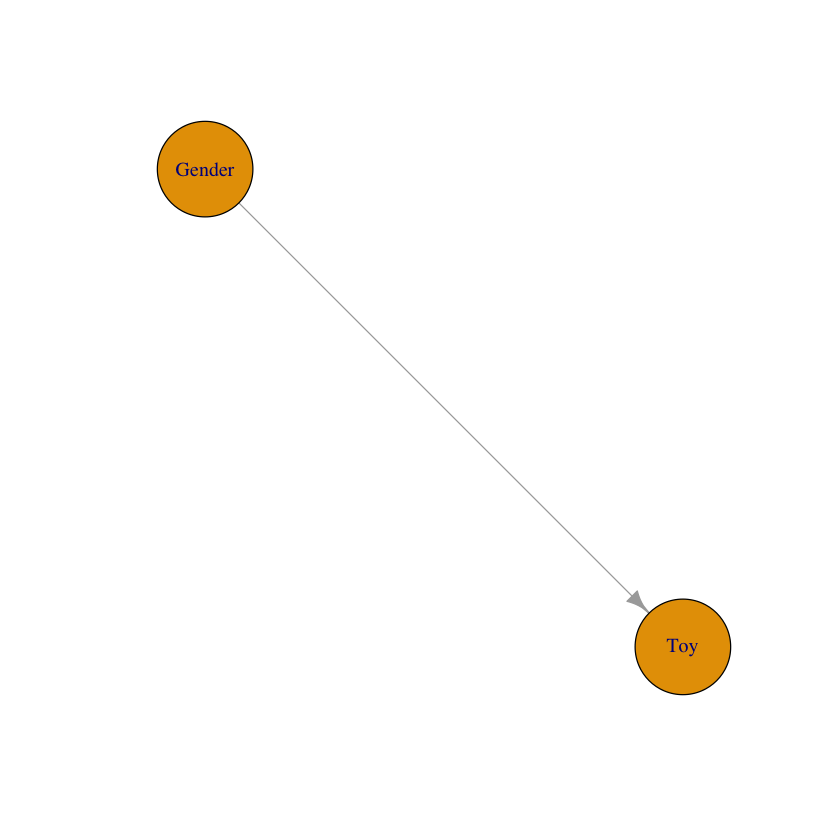

In [12]:
# Manually using a Conditional Probability Table:
gender <- cptable("Gender", values = c(0.55, 0.45), levels = c("boy","girl"))
toy <- cptable("Toy", values = c(0.67, 0.33), levels = c("car","doll"))

toy_gender <- cptable(c("Toy", "Gender"),
  # car:boy = 0.89, doll:boy = 0.10, car:girl = 0.39, doll:girl = 0.60
  values = c(0.89, 0.10, 0.39, 0.60), levels = c("car","doll"))

# Building the Bayesian Network
cpt <- compileCPT(list(gender, toy_gender))
bn <- grain(cpt, compile = FALSE)
plot(bn)

querygrain(bn, nodes=c("Toy", "Gender"), type="conditional")

### D-Separation & Causal Effect Estimation

#### Theoretical Background

**D-Separation:**

X and Y are d-separated given Z if all paths between X and Y are blocked by Z if and only if:

1. a middle node of a chain (X → B → Y) or a fork (X ← B → Y) is conditioned on (i.e. it is in Z)
2. a middle node of a collider (X → B ← Y) is **_not_** conditioned on (i.e. is _not_ in Z), and no descendant of B is in Z.

If Z blocks every path between two nodes X and Y, then X and Y are d-separated conditioning on Z and thus are conditionally independent on Z.

**Adjustment Formula:**
$$P(Y | \text{do}(X = x)) = \sum_z P(Y | X = x, Z = z) P(Z = z)$$

:::{prf:definition} Average Causal Effect
$$
ACE(a,b) = P(Y | do(X = a)) - P(Y | do(X = b))
$$
:::

**Backdoor Criterion:**
Z satisfies backdoor criterion if:
1. Z blocks all backdoor paths from X to Y
2. Z does not contain any descendants of X

:::{attention} From Backdoor Criterion to D-Separation
The backdoor criterion is related to d-Separation as follows: \
If a set $Z$ satisfies the backdoor criterion relative to $X$ and $Y$, then
$X$ and $Y$ are d-separated by $Z$ in the manipulated causal graph, which is
the causal graph obtained by **removing all arrows starting from $X$**.
:::

#### Learning Objectives
- Know D-Separation
- Estimate causal effect using the adjustment formula
- Define adjustment sets with the backdoor criterion

Are E and D d-separated by Z = {B}? TRUE 
Are E and C d-separated by Z = {A}? FALSE 
Are A and D d-separated by Z = {B, C}? FALSE 


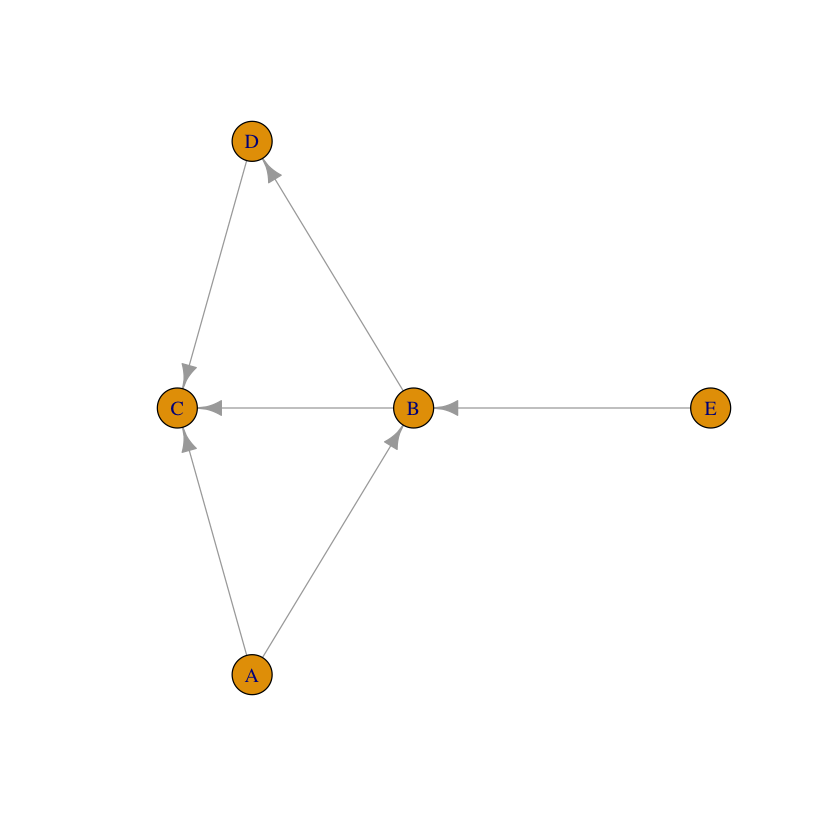

In [13]:
library(gRbase)
# List all nodes with their parents
g <- dag("A",c("B","A","E"),c("C","A","B","D"),c("D","B"),c("E"))
d.separates <- function(a,b,c,dag){
    separates(a,b,c, moralize(ancestralGraph(union(union(a,b),c),dag)))
}
plot(g)
cat("Are E and D d-separated by Z = {B}?", d.separates("E", "D", c("B"), g), "\n")
cat("Are E and C d-separated by Z = {A}?", d.separates("E", "C", c("A"), g), "\n")
cat("Are A and D d-separated by Z = {B, C}?", d.separates("A", "D", c("B", "C"), g), "\n")

### Structural Causal Models

#### Theoretical Background

**Linear SCM:**
$$\begin{aligned}
X &= f_X(E_X) \\
W &= 5X + 10Z + E_W \\
Y &= 12W + E_Y
\end{aligned}$$

**Direct vs. Total Effects:**
- **Total:** Effect through all paths
- **Direct:** Effect through direct path only

#### Learning Objectives
- Be familiar with (linear) structural causal models
- Understand direct and total causal effects
- Estimate direct and total causal effect from linear SCM

#### Key R Code Snippets

Warning message:
“Non-positive edge weight found, ignoring all weights during graph layout.”


attendance 
 -24.00246

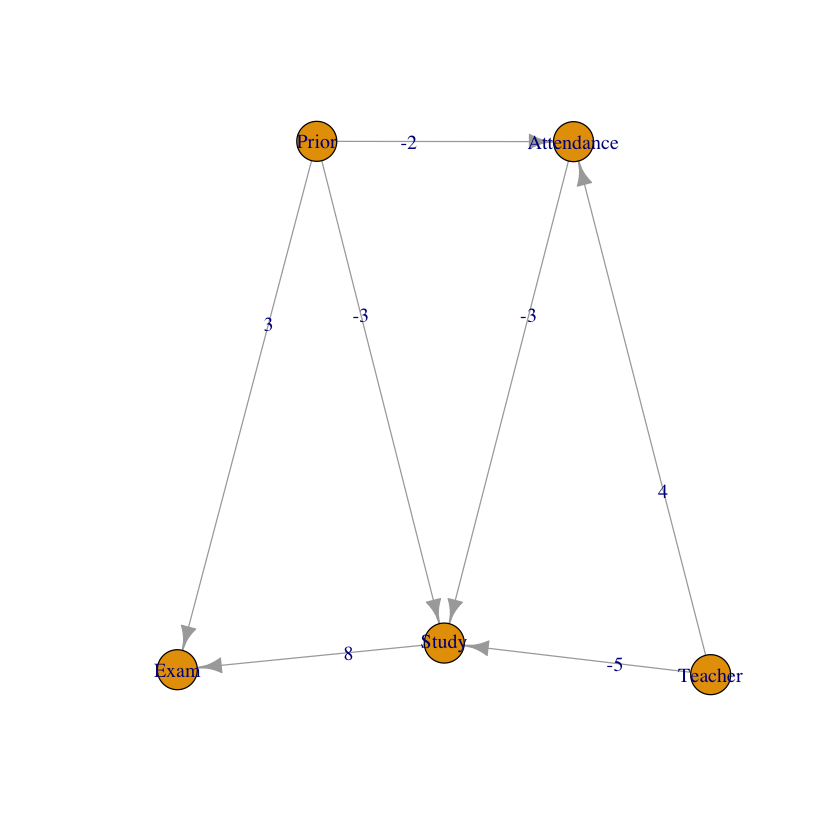

In [14]:
library(gRbase)
library(igraph)

set.seed(253)

g <- dag(
  c("Study", "Teacher", "Prior", "Attendance"),
  c("Attendance", "Prior", "Teacher"),
  c("Exam", "Study", "Prior")
)
E(g)$weight <- c(-5, -3, -3, -2, 4, 8, 3)
plot(g, edge.label = E(g)$weight)

n <- 1000000  # Sample size

# Simulate data from the SCM (using the DAG's coefficients)
prior      <- rnorm(n)
teacher    <- rnorm(n)
attendance <- -2 * prior + 4 * teacher + rnorm(n)
study      <- -3 * prior - 5 * teacher + -3 * attendance + rnorm(n)
exam       <- 3 * prior + 8 * study + rnorm(n)

# Estimate total causal effect of attendance on exam
fit <- lm(exam ~ attendance + prior + teacher)
coef(fit)["attendance"]  # Returns the estimated effect (-24 for large n)

### Advanced Topics

#### Theoretical Background

**Instrumental Variables:**
1. **Relevance:** $\text{Cov}(Z, X) \neq 0$
2. **Exclusion:** Z has no direct effect on Y except through X
3. **Exogeneity:** $\text{Cov}(Z, E) = 0$

**Two-Stage Least Squares:**
1. First stage: $X = \pi_0 + \pi_1 Z + U$
2. Second stage: $Y = \beta_0 + \beta_1 \hat{X} + E$

**Counterfactuals:**
Pearl's three-step method:
1. **Abduction:** Use the observed information to determine the values of the noise variables.
2. **Action:** Modify the causal model M by removing the structural equation for the variable X and replacing with X = x.
3. **Prediction:** Use the modified  model $M_x$ to compute the counterfactual.


Call:
lm(formula = Adv ~ Temp, data = ice_cream)

Coefficients:
(Intercept)         Temp  
     110.94         1.74  


Call:
lm(formula = Sales ~ Temp + Adv, data = ice_cream)

Coefficients:
(Intercept)         Temp          Adv  
   -258.252       22.293        2.032  



,Temp,Adv,Sales
,<dbl>,<dbl>,<dbl>
19,34.1,174.4516,885


if the temperature would have been 30 then 779.1024 ice creams would have been sold 
without advertisement on that day, 530.5143 ice creams would have been sold 
Average number of ice creams sold for days with given temperature and advertisement:  764.971 501.93 


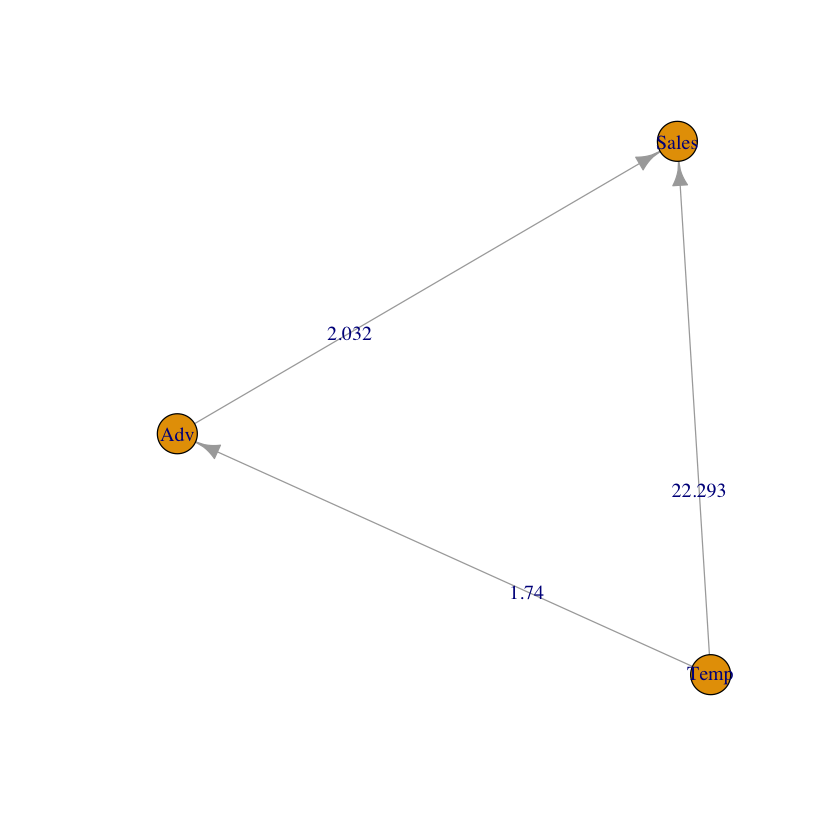

In [28]:
library(gRain)

g <- dag(
  c("Temp"),
  c("Adv", "Temp"),
  c("Sales", "Temp", "Adv")
)

load("advanced-statistical-data-analysis/ice_cream.rda")
lm.adv <- lm(Adv ~ Temp, data = ice_cream)
lm.sales <- lm(Sales ~ Temp + Adv, data = ice_cream)
print(lm.adv)
print(lm.sales)

E(g)$weight <- c(1.74, 22.293, 2.032)
plot(g, edge.label = E(g)$weight)

# look at the observation with the highest daily temperature:
ice_cream[ice_cream$Temp == max(ice_cream$Temp), ]
day19 <- ice_cream[19,]

# Counterfactuals:

# 1. Abduction:
Es <- day19$Sales - (22.293 * day19$Temp + 2.032 * day19$Adv)
Ea <- day19$Adv - (1.74 * day19$Temp)
Et <- day19$Temp

# how many ice creams would have been sold on that day, if
# temperature would have been 30? -> do(Temp = 30):

# 2. Action:
temp_c1 <- 30
adv_c1 <- 1.74 * temp_c1 + Ea

# 3. Prediction:
sales_c1 <- 22.293 * temp_c1 + 2.032 * adv_c1 + Es
cat("if the temperature would have been", temp_c1, "then", sales_c1, "ice creams would have been sold", "\n")

# do(Adv = 0):
# how many ice creams would have been sold on that day, if
# there would have been no advertisement? -> do(Adv = 0):

# 2. Action:
temp_c2 <- day19$Temp
adv_c2 <- 0

# 3. Prediction:
sales_c2 <- 22.293 * temp_c2 + 2.032 * adv_c2 + Es
cat("without advertisement on that day,", sales_c2, "ice creams would have been sold", "\n")

# Use linear regression to predict the average number of ice creams sold for the counterfactuals
x0 <- data.frame(
  Temp = c(30, day19$Temp),
  Adv  = c(day19$Adv, 0))
cat("Average number of ice creams sold for days with given temperature and advertisement: ", predict(lm.sales, newdata = x0), "\n")

# The prediction describes the average number of ice creams. In contrast,
# the counterfactual describes how many ice creams would have been sold on the
# specific day (corresponding to data point 19) if the temperature
# and advertising had been different.

**Markov Equivalence:**

- Chains and Forks are Markov equivalent, i.e. their graphs imply the  same conditional independencies.
- Colliders encode a different independence.

→ Colliders are identifiable from data, whereas fork and chains are not \
→ All graphs where we can flip the arrows without introducing new colliders and keeping all existing colliders are Markow Equivalent.

Markov Equivalence can be represented by a CPDAG.

**Completed Partially DAG (CPDAG)**

represents the Markov equivalence class of DAGs

- Directed edge: causal direction is clear (all graphs agree)
- Undirected edge: causal direction is ambiguous (graphs disagree)
- Encodes what can be identified from data alone

![CPDAG](advanced-statistical-data-analysis/CPDAG.png)

#### Learning Objectives
- Understand instrumental variables
- Be familiar with counterfactual reasoning
- Know the three steps in computing counterfactuals
- Understand Markov Equivalence

#### Key R Code Snippets

```{code-block} R
---
name: instrumental-variables
---
library(AER)
model_iv <- ivreg(Y ~ X + W | Z + W, data = mydata)
summary(model_iv)
first_stage <- lm(X ~ Z + W, data = mydata)
summary(first_stage)
```

```{code-block} R
---
name: markov-equivalence
---
library(pcalg)
dag1 <- dag(c("X", "Z", "Y"), list(c("X", "Z"), c("Z", "Y")))
dag2 <- dag(c("X", "Z", "Y"), list(c("Z", "X"), c("Z", "Y")))
meq(dag1, dag2)
```

### Causal Structure Learning

#### Theoretical Background

**Assumptions of Independence-Based Methods:**

- _Causal sufficiency_, i.e., no unobserved confounding variables.
- _Acyclicity_: No directed cycles in the graph
- _Markov_: Graph → Data, i.e., if X and Y are d-separated by Z in the graph,  then X and Y are conditionally independent given Z.
- _Faithfulness_: Data → Graph, i.e., if X and Y are conditionally independent  given Z, then X and Y are d-separated by Z in the graph.

:::{prf:algorithm} Peter-Clark (PC) Algorithm
Assuming causal sufficiency, acyclicity, Markov and faithfulness, a CPDAG can be estimated by the PC algorithm:

Input: Information about conditional independence

1. Start with a fully connected undirected graph
2. Identify the skeleton by removing edges
3. Identify colliders and orient them
4. Apply orientation rules making use of colliders and acyclicity.

Output: CPDAG

Remarks:
- Be careful when choosing $\alpha$ due to multiple testing.
- PC algorithm relies on accurate conditional independence testing
- **It’s quite hard to get accurate test results if there is not enough data.**
:::

:::{prf:theorem}
The causal graph of a SCM with Gaussian noise can only be identified up to its Markov equivalence class.
:::

$\to$ What about non-Gaussian structural equations? LinGAM to the rescue!

:::{prf:algorithm} Linear Non-Gaussian Acyclic Models (LiNGAM) Algorithm
- Assumes linear relationships with non-Gaussian errors
- Uses Independent Component Analysis (ICA) to identify causal order
- Can identify full causal graph

Input: Data matrix X

1. Apply ICA on the X to obtain $\hat{E}$ and $W = \hat{A}^{−1}$.
2. Find a permutation of rows of W that yield a matrix $\tilde{W}$̃ without zeros on diagonal and scale $\tilde{W}$̃ row-wise by its diagonal elements.
3. Compute $\hat{B} = I - \tilde{W}$.
4. Permute $\hat{B}$ until it is strictly lower triangular by also testing edges weights for significance and prune if reasonable.

Output: matrix $B$, i.e. estimated SCM
:::

#### 4 Steps of Causal Inference

1. **DAG:** Create a causal model using expert knowledge.
2. **Identification:** Determine whether and how the causal effect can be identified from the observational data.
3. **Estimation:** Estimate the causal effect from the data.
4. **Validity:** Test the estimated causal effect:

| **Method**   | **Idea**                     | **Good if ...**       |
|--------------|------------------------------|-----------------------|
| Random Cause | Add random covariate         | Estimate stable       |
| Placebo      | Randomize treatment X        | Estimate $\approx 0$ |
| Data Subset  | cross-validation / bootstrap | Estimates similar     |

#### Key R Code Snippets

Object of class 'pcAlgo', from Call:
pc(suffStat = suffStat, indepTest = gaussCItest, alpha = 0.01, 
    labels = colnames(dat), verbose = FALSE)

Nmb. edgetests during skeleton estimation:
Max. order of algorithm:  3 
Number of edgetests from m = 0 up to m = 3 :  19 29 12 4

Graphical properties of skeleton:
Max. number of neighbours:  2 at node(s) 3 
Avg. number of neighbours:  0.8 

Adjacency Matrix G:
  X Z W Y V
X . . 1 . .
Z . . 1 . .
W . . . 1 1
Y . . . . .
V . . . . .


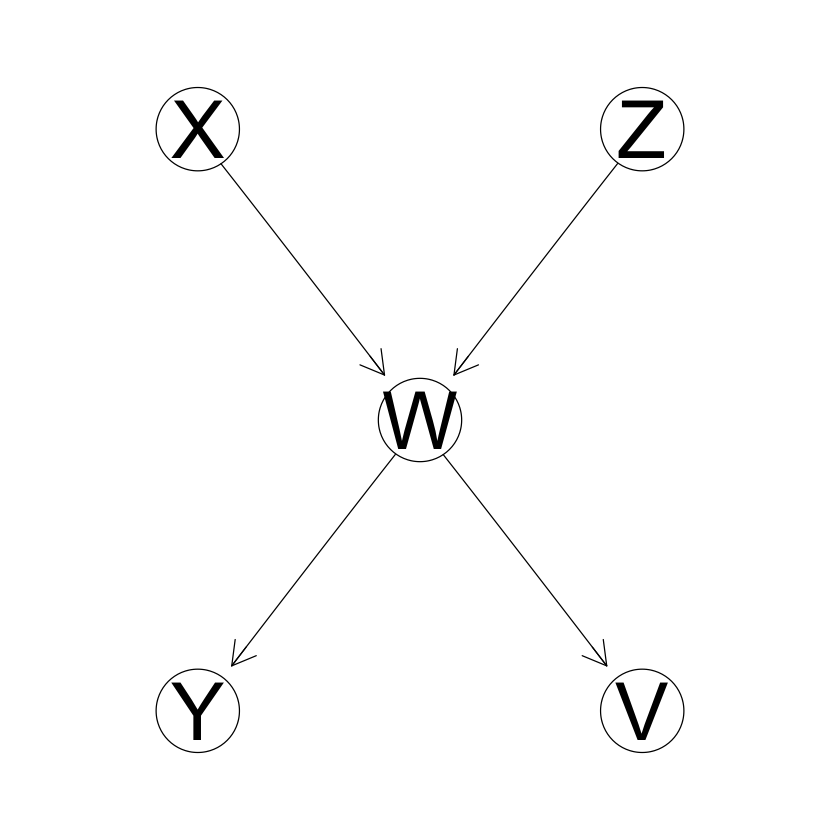

In [2]:
# PC Algorithm:
library(pcalg)

# Example data generation
set.seed(239)
N <- 500000
X <- rnorm(N)
Z <- rnorm(N)
W <- 5 * X + 10 * Z + rnorm(N)
Y <- 12 * W + rnorm(N)
V <- 8 * W + rnorm(N)
dat <- cbind(X, Z, W, Y, V)

suffStat <- list(C = cor(dat), n = nrow(dat))
pc.fit <- pc(
    suffStat,
    indepTest = gaussCItest,
    alpha = 0.01,
    labels = colnames(dat),
    verbose = FALSE)
summary(pc.fit)  # There are 19 + 29 + 12 + 4 tests!!
plot(pc.fit, main = "") # Needs a title!

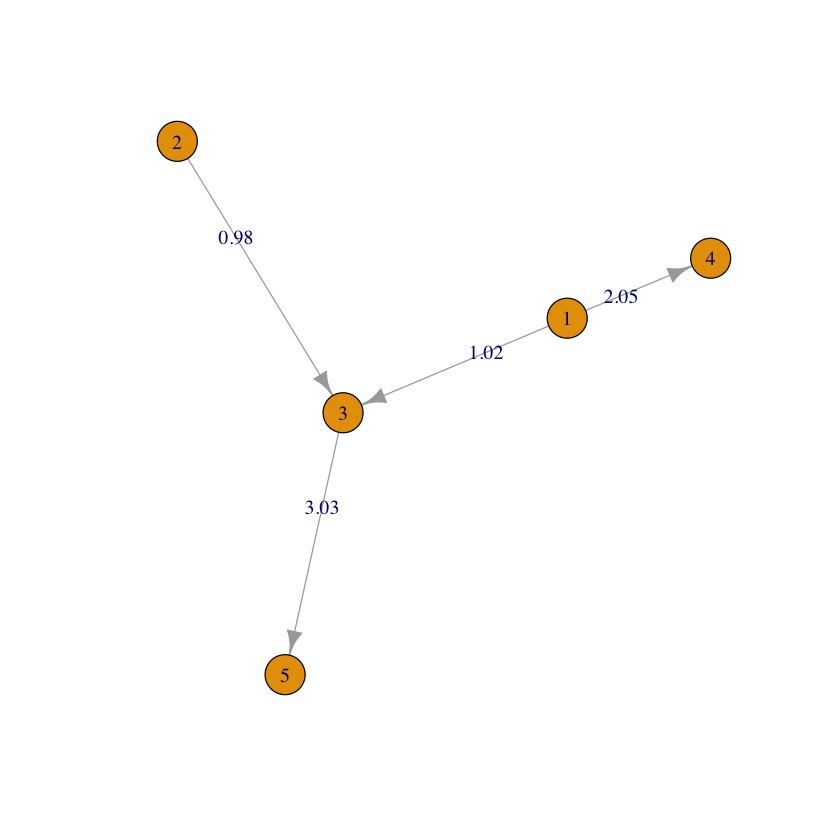

In [20]:
# LiNGAM Algorithm:
library(pcalg)

# Linear SCM with uniform distributed noise
set.seed(145)
N <- 2000
x1 <- runif(N,-.5,.5)
x2 <- runif(N,-.3,3)
x3 <- x1 + x2 + runif(N,-.7,.7)
x4 <- 2*x1 + runif(N,-.5,.5)
x5 <- 3*x3 + runif(N,-1,1)
data <- cbind(x1,x2,x3,x4,x5)

# Apply LiNGAM
fit.ex2 <- lingam(data)

# Transpose the matrix to correct edge directions
adj_matrix <- t(fit.ex2$Bpruned)

# Convert to igraph and plot
g <- graph_from_adjacency_matrix(
  adj_matrix,
  mode = "directed",
  weighted = TRUE
)
plot(g, edge.label = round(E(g)$weight, 2))  # Show rounded weights